Sander Coscia, Jamie Rapal
CS 548 Project 3
Prof. Shraga
10/25/2024

Here is the code to some EDA charts, the SVR and decision tree models, and the LIME.

Here is the Gender Distribution EDA chart

Processing file: 9_1_2_20161219204347420.jpg.chip.jpg
Processing file: 1_1_2_20161219154612988.jpg.chip.jpg
Processing file: 16_0_0_20170104003740977.jpg.chip.jpg
Processing file: 1_1_3_20161219230734016.jpg.chip.jpg
Processing file: 26_1_1_20170103181931657.jpg.chip.jpg
Processing file: 2_0_2_20161219141650121.jpg.chip.jpg
Processing file: 53_1_0_20170110143534851.jpg.chip.jpg
Processing file: 36_1_4_20170104172843788.jpg.chip.jpg
Processing file: 37_0_0_20170104205628245.jpg.chip.jpg
Processing file: 10_0_1_20170110223848885.jpg.chip.jpg
Processing file: 1_0_2_20161219205313061.jpg.chip.jpg
Processing file: 52_0_0_20170104212337021.jpg.chip.jpg
Processing file: 18_1_0_20170109212830216.jpg.chip.jpg
Processing file: 34_1_3_20170104235537715.jpg.chip.jpg
Processing file: 34_1_4_20170103230336761.jpg.chip.jpg
Processing file: 34_1_0_20170104174537956.jpg.chip.jpg
Processing file: 30_0_0_20170104000150443.jpg.chip.jpg
Processing file: 75_1_3_20170110175327928.jpg.chip.jpg
Processing file

/var/folders/wz/m351thxn2fxf9m9qhvjc__nh0000gn/T/ipykernel_34332/771707244.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Gender', data=gender_df, palette='pastel')


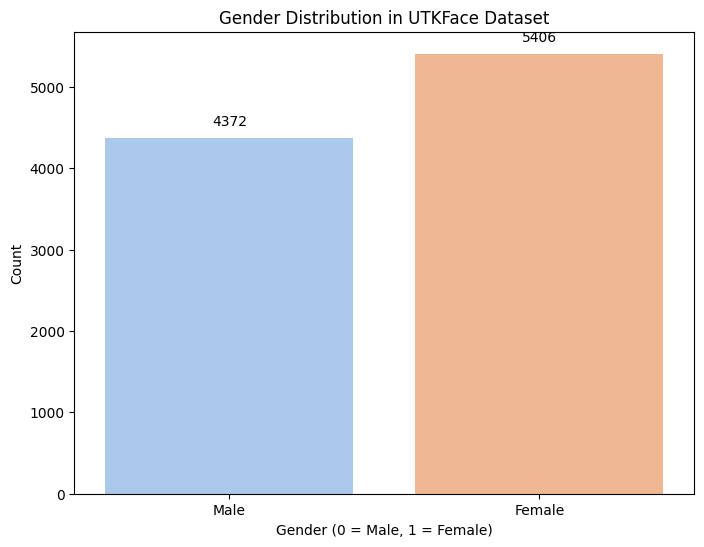

In [1]:
import os
import numpy as np
import pandas as pd
from collections import defaultdict
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns

image_directory = '/Users/sandersander/Documents/CS 548/archive (3)/utkface_aligned_cropped/crop_part1'
images_array = []
img_sizes = defaultdict(int)
age_labels = []
gender_labels = []

# Loop through each image in the directory
for filename in os.listdir(image_directory):
    if filename.endswith('.jpg'):
        print(f"Processing file: {filename}")
        labels = filename.split('_')

        if len(labels) >= 4:  
            try:
                age = int(labels[0])
                gender = int(labels[1])

                age_labels.append(age)
                gender_labels.append(gender)

                img_path = os.path.join(image_directory, filename)
                img = Image.open(img_path)

                img_sizes[img.size] += 1


                img = img.convert('L')
                img_array = np.array(img).flatten()
                images_array.append(img_array)
            except ValueError as ve:
                print(f"ValueError for {filename}: {ve}") 
        else:
            print(f"Unexpected filename format for {filename}: {labels}") 
# Gender Distribution Analysis
gender_df = pd.DataFrame(gender_labels, columns=['Gender'])

plt.figure(figsize=(8,6))
ax = sns.countplot(x='Gender', data=gender_df, palette='pastel')
plt.title('Gender Distribution in UTKFace Dataset')
plt.xlabel('Gender (0 = Male, 1 = Female)')
plt.ylabel('Count')
plt.xticks([0, 1], ['Male', 'Female'])

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=10, color='black', xytext=(0, 12),
                textcoords='offset points')

plt.show()


Here is the Age Distribution by Gender EDA chart

<Figure size 1800x600 with 0 Axes>

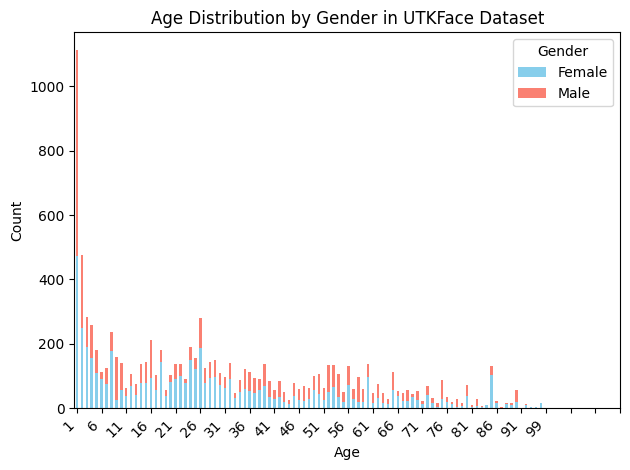

In [2]:
import os
import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize lists to hold age and gender data
age_labels = []
gender_labels = []

# Regular expression pattern to extract age and gender
pattern = re.compile(r'(\d+)_(\d+)_\d+_\d+\.jpg')

# Loop through each file to extract age and gender
for filename in os.listdir(image_directory):
    if filename.endswith('.jpg'):
        match = pattern.match(filename)
        
        if match:
            age = int(match.group(1))
            gender = int(match.group(2))
            
            # Append to the lists
            age_labels.append(age)
            gender_labels.append(gender)

data = pd.DataFrame({'Age': age_labels, 'Gender': gender_labels})

data['Gender'] = data['Gender'].map({0: 'Male', 1: 'Female'})

age_gender_counts = data.groupby(['Age', 'Gender']).size().unstack(fill_value=0)

# Plot
plt.figure(figsize=(18, 6))
age_gender_counts.plot(kind='bar', stacked=True, color=['skyblue', 'salmon'])
plt.title('Age Distribution by Gender in UTKFace Dataset')
plt.xlabel('Age')
plt.ylabel('Count')

plt.xticks(ticks=range(0, age_gender_counts.index.max()+1, 5), rotation=45, ha='right', fontsize=10)

plt.legend(title='Gender')
plt.tight_layout()

plt.show()



Here is the Ethnicity Distribution EDA chart

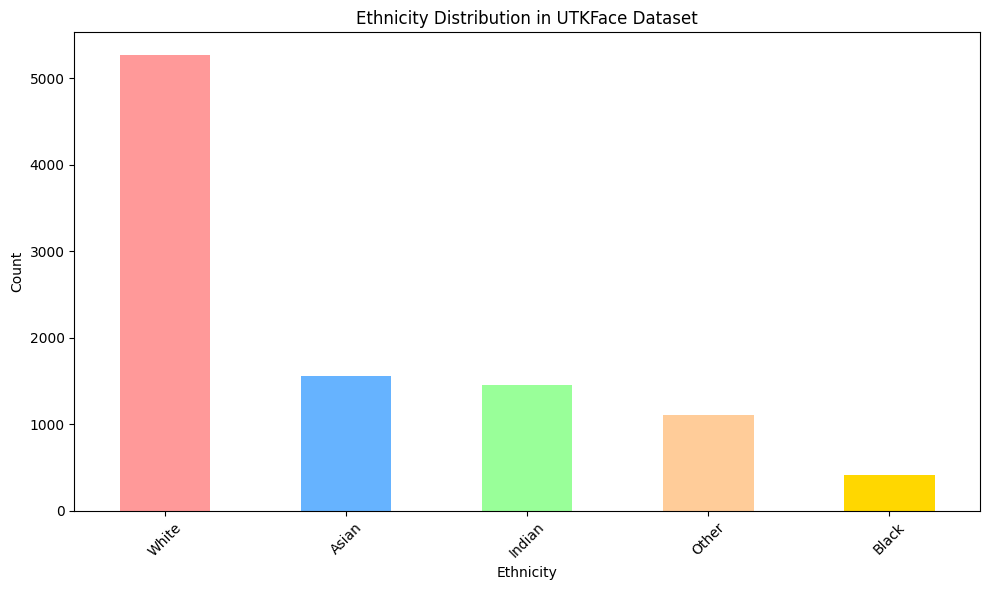

In [3]:

# Initialize lists to hold ethnicity data
ethnicity_labels = []

pattern = re.compile(r'(\d+)_(\d+)_(\d+)_\d+\.jpg')

# Loop through each file to extract ethnicity
for filename in os.listdir(image_directory):
    if filename.endswith('.jpg'):
        match = pattern.match(filename)
        
        if match:
            ethnicity = int(match.group(3)) 
            ethnicity_labels.append(ethnicity)


data = pd.DataFrame({'Ethnicity': ethnicity_labels})

ethnicity_map = {0: 'White', 1: 'Black', 2: 'Asian', 3: 'Indian', 4: 'Other'}
data['Ethnicity'] = data['Ethnicity'].map(ethnicity_map)

ethnicity_counts = data['Ethnicity'].value_counts()

# Plot
plt.figure(figsize=(10, 6))
ethnicity_counts.plot(kind='bar', color=['#FF9999', '#66B3FF', '#99FF99', '#FFCC99', '#FFD700'])
plt.title('Ethnicity Distribution in UTKFace Dataset')
plt.xlabel('Ethnicity')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

Here is the plain SVR model

Mean Absolute Error (MAE): 13.482490242344182
Mean Squared Error (MSE): 351.06438671040684
Root Mean Squared Error (RMSE): 18.73671227057743
R-squared (R²): 0.42017107003696086


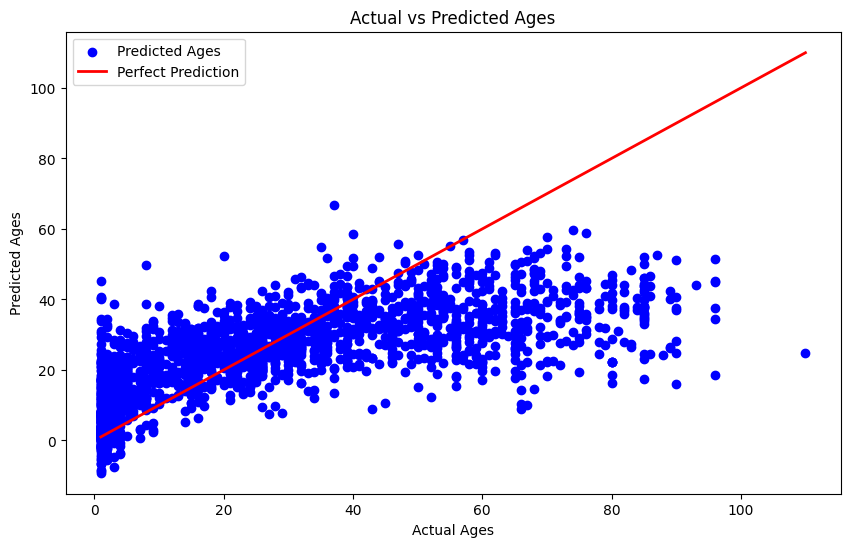

In [1]:
import os
import numpy as np
import pandas as pd
from PIL import Image
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

images_array = []
labels = []

# Load the images and labels
for filename in os.listdir(image_directory):
    if filename.endswith('.jpg'):
        
        age = int(filename.split('_')[0])
        
        img_path = os.path.join(image_directory, filename)
        img = Image.open(img_path).convert('L')
        
        img = img.resize((64, 64))
        
        img_array = np.array(img).flatten()
        
        images_array.append(img_array)
        labels.append(age)

# Convert the image data and labels into arrays
X = np.array(images_array)
y = np.array(labels) 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

svr = SVR(kernel='rbf')

svr.fit(X_train, y_train)

y_pred = svr.predict(X_test)

#Evaluation Metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"R-squared (R²): {r2}")

# Plot actual vs predicted
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, color='blue', label='Predicted Ages')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', lw=2, label='Perfect Prediction')
plt.title('Actual vs Predicted Ages')
plt.xlabel('Actual Ages')
plt.ylabel('Predicted Ages')
plt.legend()
plt.show()


Here is the grid search SVR model

Fitting 3 folds for each of 4 candidates, totalling 12 fits
[CV] END ...........C=1, epsilon=0.1, gamma=0.01, kernel=rbf; total time= 8.2min
[CV] END ...........C=1, epsilon=0.1, gamma=0.01, kernel=rbf; total time= 8.3min
[CV] END ...........C=1, epsilon=0.1, gamma=0.01, kernel=rbf; total time= 8.3min
[CV] END ............C=1, epsilon=0.1, gamma=0.1, kernel=rbf; total time= 8.3min
[CV] END ............C=1, epsilon=0.1, gamma=0.1, kernel=rbf; total time= 7.1min
[CV] END ..........C=10, epsilon=0.1, gamma=0.01, kernel=rbf; total time= 7.1min
[CV] END ............C=1, epsilon=0.1, gamma=0.1, kernel=rbf; total time= 7.2min
[CV] END ..........C=10, epsilon=0.1, gamma=0.01, kernel=rbf; total time= 7.2min
[CV] END ...........C=10, epsilon=0.1, gamma=0.1, kernel=rbf; total time= 6.4min
[CV] END ..........C=10, epsilon=0.1, gamma=0.01, kernel=rbf; total time= 6.5min
[CV] END ...........C=10, epsilon=0.1, gamma=0.1, kernel=rbf; total time= 6.4min
[CV] END ...........C=10, epsilon=0.1, gamma=0.1,

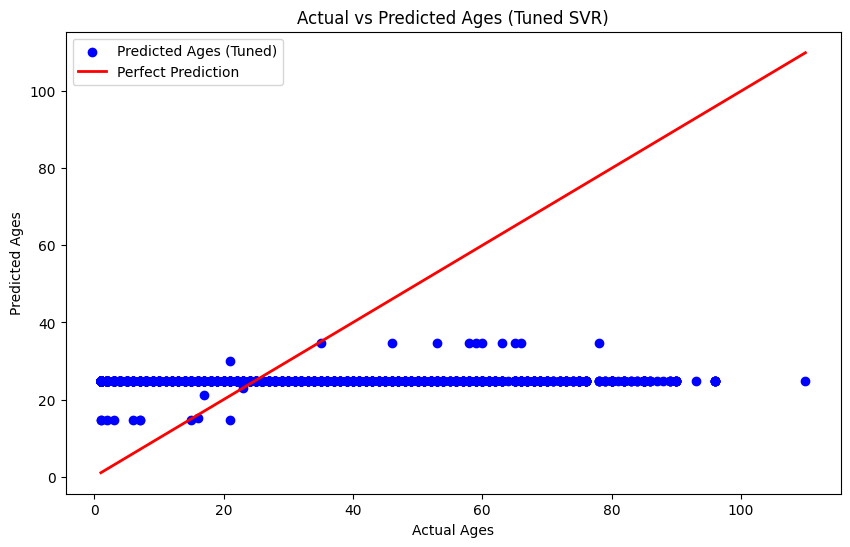

In [8]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

# Define a reduced parameter grid for tuning
param_grid = {
    'C': [1, 10],  
    'gamma': [0.01, 0.1], 
    'epsilon': [0.1],  
    'kernel': ['rbf'] 
}

# Initialize the SVR model
svr = SVR()

# Initialize GridSearchCV with fewer CV folds and parallel processing
grid_search = GridSearchCV(svr, param_grid, cv=3, scoring='neg_mean_squared_error', verbose=2, n_jobs=-1)

# Fit the model on the training data
grid_search.fit(X_train, y_train)

# Get the best parameters from the grid search
best_params = grid_search.best_params_
print(f"Best Parameters: {best_params}")

# Train the SVR model using the best parameters
svr_best = SVR(kernel=best_params['kernel'], C=best_params['C'], gamma=best_params['gamma'], epsilon=best_params['epsilon'])
svr_best.fit(X_train, y_train)

y_pred_best = svr_best.predict(X_test)

# Evaluate
mae_best = mean_absolute_error(y_test, y_pred_best)
mse_best = mean_squared_error(y_test, y_pred_best)
rmse_best = np.sqrt(mse_best)
r2_best = r2_score(y_test, y_pred_best)

print(f"Mean Absolute Error after tuning: {mae_best}")
print(f"Mean Squared Error after tuning: {mse_best}")
print(f"Root Mean Squared Error after tuning: {rmse_best}")
print(f"R-squared after tuning: {r2_best}")

# Plot
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_best, color='blue', label='Predicted Ages (Tuned)')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', lw=2, label='Perfect Prediction')
plt.title('Actual vs Predicted Ages (Tuned SVR)')
plt.xlabel('Actual Ages')
plt.ylabel('Predicted Ages')
plt.legend()
plt.show()



Here is the PCA SVR model

Mean Absolute Error (MAE): 13.41080839904978
Mean Squared Error (MSE): 348.3077426573266
Root Mean Squared Error (RMSE): 18.66300465244883
R-squared (R²): 0.42472402964235934


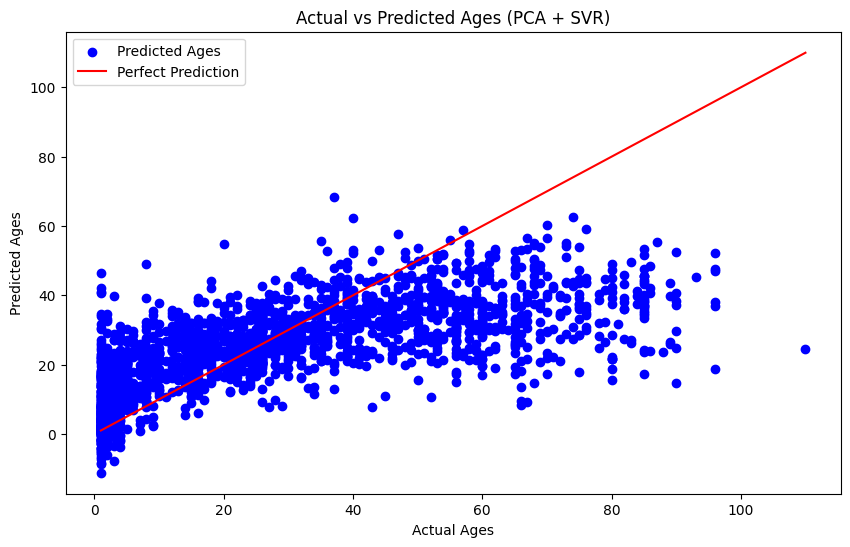

In [2]:
from sklearn.decomposition import PCA
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

# Apply PCA to reduce the number of components
pca = PCA(n_components=100)  # Reduce to 100 components
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

# Train an SVR model on the reduced dataset
svr = SVR(kernel='rbf', C=1.0, epsilon=0.1) 
svr.fit(X_train_pca, y_train)

#Evaluate
y_pred = svr.predict(X_test_pca)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f'Mean Absolute Error (MAE): {mae}')
print(f'Mean Squared Error (MSE): {mse}')
print(f'Root Mean Squared Error (RMSE): {rmse}')
print(f'R-squared (R²): {r2}')

# Plot
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, color='blue', label='Predicted Ages')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', label='Perfect Prediction')
plt.xlabel('Actual Ages')
plt.ylabel('Predicted Ages')
plt.title('Actual vs Predicted Ages (PCA + SVR)')
plt.legend()
plt.show()



Here is the Polynomial kernel SVR model

Mean Absolute Error (Polynomial Kernel): 11.807536072199513
Mean Squared Error (Polynomial Kernel): 244.02943376517143
Root Mean Squared Error (Polynomial Kernel): 15.62144147526634
R-squared (Polynomial Kernel): 0.5969533486851082


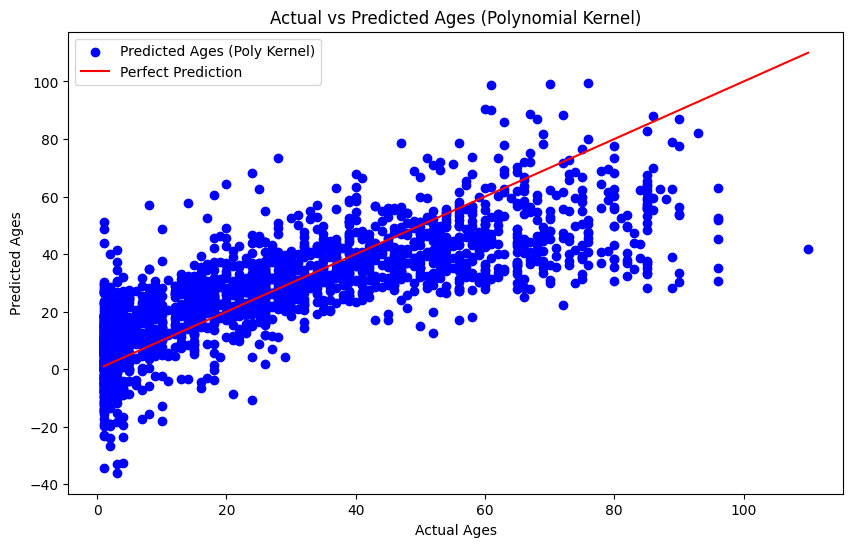

In [3]:
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Train an SVR model with a polynomial kernel
svr_poly = SVR(kernel='poly', degree=3, C=1.0, epsilon=0.1)  # Degree can be adjusted
svr_poly.fit(X_train, y_train)

# Predict and evaluate
y_pred_poly = svr_poly.predict(X_test)
mae_poly = mean_absolute_error(y_test, y_pred_poly)
mse_poly = mean_squared_error(y_test, y_pred_poly)
rmse_poly = np.sqrt(mse_poly)
r2_poly = r2_score(y_test, y_pred_poly)

print(f'Mean Absolute Error (Polynomial Kernel): {mae_poly}')
print(f'Mean Squared Error (Polynomial Kernel): {mse_poly}')
print(f'Root Mean Squared Error (Polynomial Kernel): {rmse_poly}')
print(f'R-squared (Polynomial Kernel): {r2_poly}')

# Plot
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_poly, color='blue', label='Predicted Ages (Poly Kernel)')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', label='Perfect Prediction')
plt.xlabel('Actual Ages')
plt.ylabel('Predicted Ages')
plt.title('Actual vs Predicted Ages (Polynomial Kernel)')
plt.legend()
plt.show()



Here is the plain Random Forest model

Mean Absolute Error (Random Forest): 11.908060059402086
Mean Squared Error (Random Forest): 258.9743079869647
Root Mean Squared Error (Random Forest): 16.092678707628654
R-squared (Random Forest): 0.5722699266221271


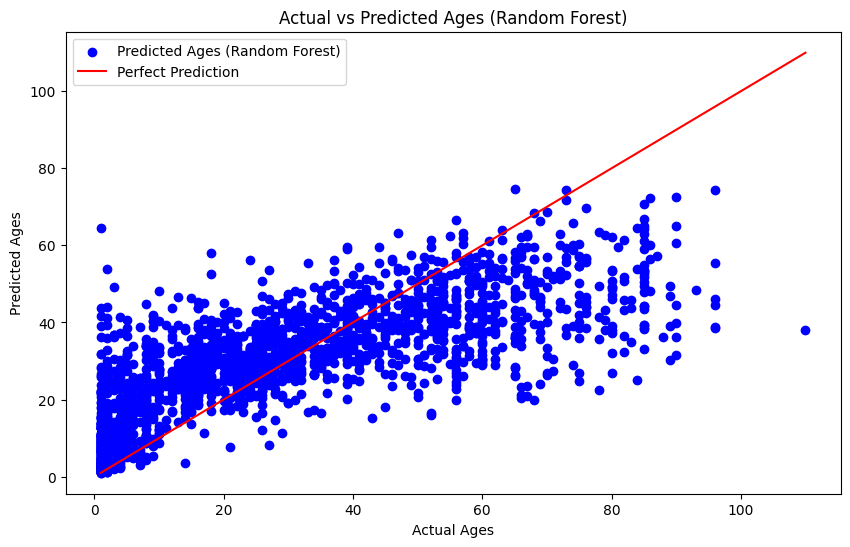

In [4]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

# Instantiate the Random Forest Regressor
rf = RandomForestRegressor(n_estimators=30, random_state=42, n_jobs=-1)

rf.fit(X_train, y_train)

# Predict on the test set
y_pred_rf = rf.predict(X_test)

# Evaluate
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f'Mean Absolute Error (Random Forest): {mae_rf}')
print(f'Mean Squared Error (Random Forest): {mse_rf}')
print(f'Root Mean Squared Error (Random Forest): {rmse_rf}')
print(f'R-squared (Random Forest): {r2_rf}')

# Plot
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_rf, color='blue', label='Predicted Ages (Random Forest)')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', label='Perfect Prediction')
plt.xlabel('Actual Ages')
plt.ylabel('Predicted Ages')
plt.title('Actual vs Predicted Ages (Random Forest)')
plt.legend()
plt.show()


Here is the PCA Random Forest model

Mean Absolute Error (Random Forest + PCA): 15.062898691855747
Mean Squared Error (Random Forest + PCA): 368.53799341411144
Root Mean Squared Error (Random Forest + PCA): 19.197343394702077
R-squared (Random Forest + PCA): 0.3913111142535174


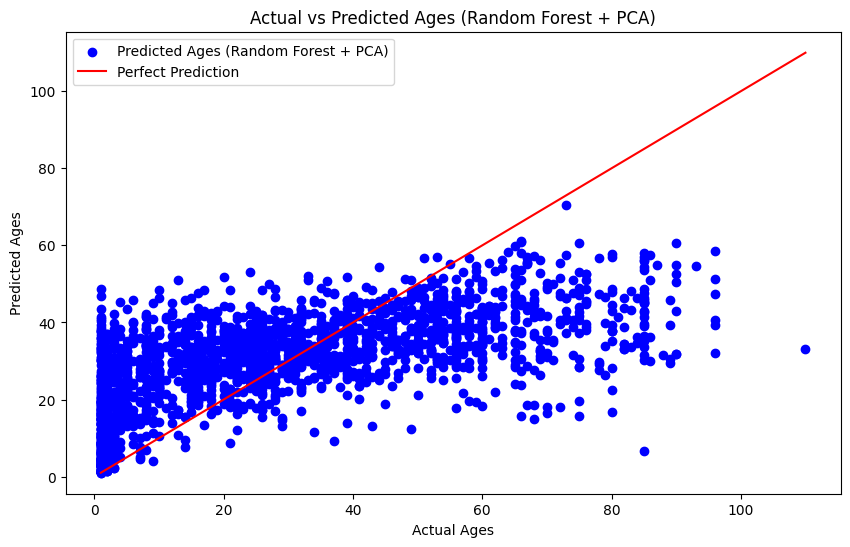

In [5]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.decomposition import PCA
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

# Apply PCA to reduce dimensionality
pca = PCA(n_components=500)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

rf = RandomForestRegressor(n_estimators=30, random_state=42, n_jobs=-1)

rf.fit(X_train_pca, y_train)

# Predict
y_pred = rf.predict(X_test_pca)

# Evaluate
mae_rf = mean_absolute_error(y_test, y_pred)
mse_rf = mean_squared_error(y_test, y_pred)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred)

print(f'Mean Absolute Error (Random Forest + PCA): {mae_rf}')
print(f'Mean Squared Error (Random Forest + PCA): {mse_rf}')
print(f'Root Mean Squared Error (Random Forest + PCA): {rmse_rf}')
print(f'R-squared (Random Forest + PCA): {r2_rf}')

# Plot
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, color='blue', label='Predicted Ages (Random Forest + PCA)')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', label='Perfect Prediction')
plt.xlabel('Actual Ages')
plt.ylabel('Predicted Ages')
plt.title('Actual vs Predicted Ages (Random Forest + PCA)')
plt.legend()
plt.show()



Here is the Random Forest model with 50 estimators rather than 30

Mean Absolute Error (Random Forest): 11.815309450774174
Mean Squared Error (Random Forest): 254.52273590473303
Root Mean Squared Error (Random Forest): 15.953768705379085
R-squared (Random Forest): 0.5796222824144077


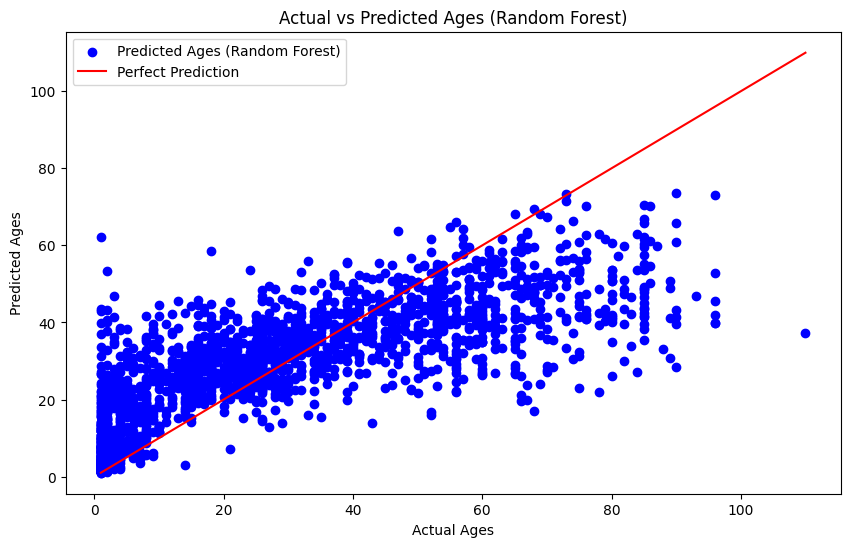

In [6]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

# Random Forest Regressor
rf = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)

rf.fit(X_train, y_train)

# Predict on the test set
y_pred_rf = rf.predict(X_test)

# Evaluate
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f'Mean Absolute Error (Random Forest): {mae_rf}')
print(f'Mean Squared Error (Random Forest): {mse_rf}')
print(f'Root Mean Squared Error (Random Forest): {rmse_rf}')
print(f'R-squared (Random Forest): {r2_rf}')

# Plot
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_rf, color='blue', label='Predicted Ages (Random Forest)')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', label='Perfect Prediction')
plt.xlabel('Actual Ages')
plt.ylabel('Predicted Ages')
plt.title('Actual vs Predicted Ages (Random Forest)')
plt.legend()
plt.show()


Here is the Random Forest model with different hyperparameters. Max depth set to 20

Mean Absolute Error (Tuned Random Forest): 11.841196849789407
Mean Squared Error (Tuned Random Forest): 257.507383778034
Root Mean Squared Error (Tuned Random Forest): 16.047036604246717
R-squared (Tuned Random Forest): 0.5746927445626514


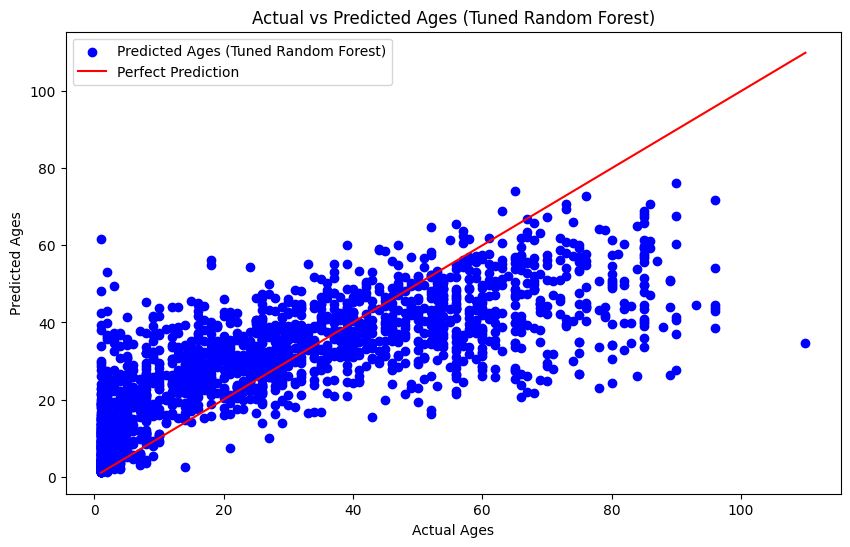

In [7]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

# Random Forest Regressor with tweaked hyperparameters
rf_tuned = RandomForestRegressor(
    n_estimators=30,          
    max_depth=20,             # Allow trees to grow deeper
    min_samples_split=5,      
    random_state=42,
    n_jobs=-1
)

rf_tuned.fit(X_train, y_train)

# Predict
y_pred_tuned = rf_tuned.predict(X_test)

# Evaluate
mae_rf_tuned = mean_absolute_error(y_test, y_pred_tuned)
mse_rf_tuned = mean_squared_error(y_test, y_pred_tuned)
rmse_rf_tuned = np.sqrt(mse_rf_tuned)
r2_rf_tuned = r2_score(y_test, y_pred_tuned)

print(f'Mean Absolute Error (Tuned Random Forest): {mae_rf_tuned}')
print(f'Mean Squared Error (Tuned Random Forest): {mse_rf_tuned}')
print(f'Root Mean Squared Error (Tuned Random Forest): {rmse_rf_tuned}')
print(f'R-squared (Tuned Random Forest): {r2_rf_tuned}')

# Plot
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_tuned, color='blue', label='Predicted Ages (Tuned Random Forest)')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', label='Perfect Prediction')
plt.xlabel('Actual Ages')
plt.ylabel('Predicted Ages')
plt.title('Actual vs Predicted Ages (Tuned Random Forest)')
plt.legend()
plt.show()



Here is the code for the LIME analysis

In [9]:
!pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 2.1 MB/s eta 0:00:00a 0:00:01
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 3.4 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 315.4/315.4 kB 3.8 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 227.3/227.3 kB 5.2 MB/s eta 0:00:0000:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 5.3 MB/s eta 0:00:0000:0100:01m
Using legacy 'setup.py install' for lime, since package 'wheel' is not installed.
  Running setup.py install for lime ... done

[notice] A new release of pip available: 22.2.2 -> 24.2
[notice] To update, run: pip install --upgrade pip


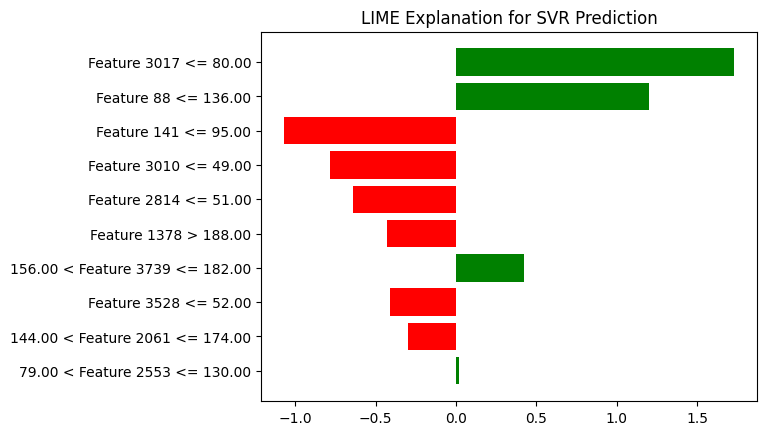

In [10]:
import numpy as np
import pandas as pd
from lime import lime_tabular
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

svr_poly = SVR(kernel='poly', degree=3, C=1.0, epsilon=0.1)
svr_poly.fit(X_train, y_train)

# Use LIME to explain the predictions
explainer = lime_tabular.LimeTabularExplainer(X_train, feature_names=[f'Feature {i}' for i in range(X_train.shape[1])], 
                                               class_names=['Age'], mode='regression')

# Choose an instance to explain (for example, the first instance in the test set)
instance_to_explain = X_test[0].reshape(1, -1)

# Generate LIME explanation
explanation = explainer.explain_instance(instance_to_explain[0], svr_poly.predict, num_features=10)

# Display the explanation
explanation.show_in_notebook(show_table=True)

# If you want to visualize the explanation
explanation.as_pyplot_figure()
plt.title('LIME Explanation for SVR Prediction')
plt.show()


Below are citations for code from ChatGPT including the prompt and output


Prompt: I have this dataset of images, how do i make and put them into a directory.
output:
# Loop through each image in the directory
for filename in os.listdir(image_directory):
    if filename.endswith('.jpg'):
        print(f"Processing file: {filename}")
        labels = filename.split('_')

        # Ensure filename has expected parts
        if len(labels) >= 4:  
            try:
                age = int(labels[0])
                gender = int(labels[1])

                # Store the labels
                age_labels.append(age)
                gender_labels.append(gender)

                # Process the image (if necessary)
                img_path = os.path.join(image_directory, filename)
                img = Image.open(img_path)

                # Track image sizes for further analysis
                img_sizes[img.size] += 1

                # Convert to grayscale and flatten
                img = img.convert('L')
                img_array = np.array(img).flatten()
                images_array.append(img_array)
            except ValueError as ve:
                print(f"ValueError for {filename}: {ve}")  # Log parsing errors
        else:
            print(f"Unexpected filename format for {filename}: {labels}")  # Log unexpected formats

Prompt: How do I load images into a directory for this model?
Output:
# Load the images and labels
for filename in os.listdir(image_directory):
    if filename.endswith('.jpg'):
        # Extract the age from the filename (format: age_gender_race_date.jpg)
        age = int(filename.split('_')[0])
        
        # Load the image and convert it to grayscale
        img_path = os.path.join(image_directory, filename)
        img = Image.open(img_path).convert('L')  # Convert to grayscale
        
        # Resize the image to a smaller size (e.g., 64x64) to reduce computation
        img = img.resize((64, 64))
        
        # Flatten the image into a feature vector
        img_array = np.array(img).flatten()
        
        # Append the image array and the corresponding age label
        images_array.append(img_array)
        labels.append(age)

Prompt: What are differnt hyperparameters i can adjust for the rndom forest model? what could be the code to include?
Output:
# Random Forest Regressor with tweaked hyperparameters
rf_tuned = RandomForestRegressor(
    n_estimators=30,          # Increase the number of trees
    max_depth=20,             # Allow trees to grow deeper
    min_samples_split=5,      # Control minimum number of samples to split
    random_state=42,
    n_jobs=-1
)

Prompt: How do I incorperated gridsearch into the SVR model
Output:
# Define a reduced parameter grid for tuning
param_grid = {
    'C': [1, 10],  # Reduced number of values for C
    'gamma': [0.01, 0.1],  # Reduced number of values for gamma
    'epsilon': [0.1],  # Fixed epsilon to speed up
    'kernel': ['rbf']  # Only testing the RBF kernel
}

# Initialize the SVR model
svr = SVR()

# Initialize GridSearchCV with fewer CV folds and parallel processing
grid_search = GridSearchCV(svr, param_grid, cv=3, scoring='neg_mean_squared_error', verbose=2, n_jobs=-1)

# Fit the model on the training data
grid_search.fit(X_train, y_train)

# Get the best parameters from the grid search
best_params = grid_search.best_params_
print(f"Best Parameters: {best_params}")

Prompt: How do i use the LIME technique to explain this model, what whould the code be?
Output:
# Create the LIME explainer
explainer = LimeTabularExplainer(X_train, feature_names=[f'Feature {i}' for i in range(X_train.shape[1])], 
                                   class_names=['Age'], 
                                   mode='regression')

Prompt: How do I use the SHAP technique to do the same this as the LIME technique? What would be the code?
Output:
import shap
import numpy as np
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Assuming you've already split your data into X_train, X_test, y_train, y_test

# Train the SVR model with a polynomial kernel
svr_poly = SVR(kernel='poly', degree=3, C=1.0, epsilon=0.1)  # Adjust parameters as needed
svr_poly.fit(X_train, y_train)

# Predict using the SVR model
y_pred_poly = svr_poly.predict(X_test)

# Calculate evaluation metrics
mae_poly = mean_absolute_error(y_test, y_pred_poly)
mse_poly = mean_squared_error(y_test, y_pred_poly)
rmse_poly = np.sqrt(mse_poly)
r2_poly = r2_score(y_test, y_pred_poly)

# Display the evaluation metrics
print(f'Mean Absolute Error (Polynomial Kernel): {mae_poly}')
print(f'Mean Squared Error (Polynomial Kernel): {mse_poly}')
print(f'Root Mean Squared Error (Polynomial Kernel): {rmse_poly}')
print(f'R-squared (Polynomial Kernel): {r2_poly}')

# Initialize SHAP Explainer
explainer = shap.KernelExplainer(svr_poly.predict, X_train)

# Calculate SHAP values for the test set
shap_values = explainer.shap_values(X_test)

# Visualize the SHAP values for the first instance in the test set
shap.initjs()  # Initialize JavaScript for interactive plots
shap.force_plot(explainer.expected_value, shap_values[0], X_test[0])
